# Projet: Brain Tumor classification

This experimental project focuses on the diagnosis of brain tumors using brain MRIs. Its goal is to detect tumors and classify them based on their type, grade, and location. Unlike traditional approaches that use a separate model for each task, this work proposes a single model based on Convolutional Neural Networks (CNNs) to perform multiple classification tasks. Tumor localization is also carried out through segmentation using a CNN-based model.


**Prepared by:** Souha Benelaam

### DataSet
Dataset was obtained from Kaggle: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset?resource=download

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import cv2
from torchvision import transforms, datasets
import torchvision


#### Loading the MRI images

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # MRI images are Grayscale so we don't need to work on 3 channels
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

training_set= datasets.ImageFolder(root='data/Training', transform=transform)
training_loader = DataLoader(training_set, batch_size=16, shuffle=True)

test_set = datasets.ImageFolder(root='data/Testing', transform=transform)
test_loader = DataLoader(test_set, batch_size= 16, shuffle=False)
classes = ('notumor', 'meningioma', 'pituitary', 'glioma')

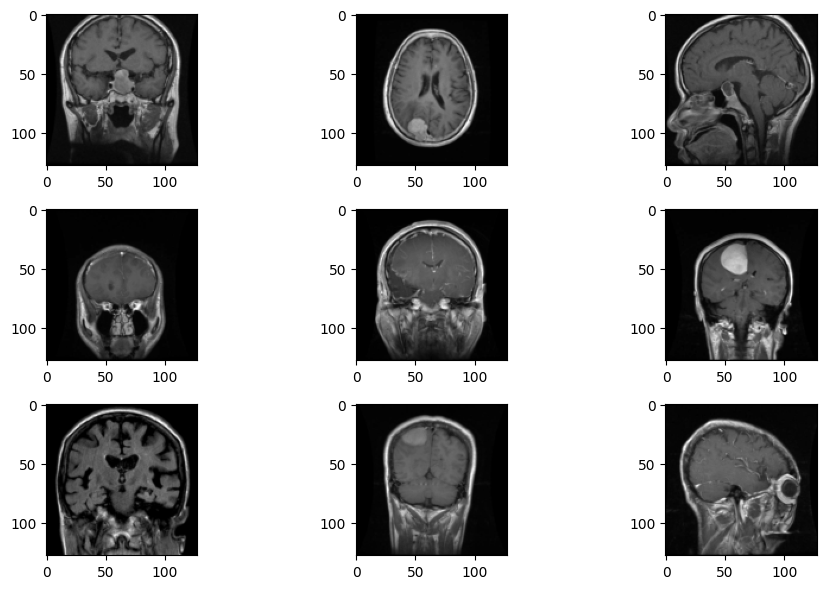

In [ ]:
images, labels = next(iter(training_loader))  # one batch

plt.figure(figsize=(10, 6))
for i in range(9):
    img = images[i].squeeze(0)
    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')

plt.tight_layout()
plt.show()

## CNN Model

We used a Resnet architecture (which replaced our old simple CNN model. We still kept it in the following code for reference.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

class MRI_ResNet(nn.Module):
    def __init__(self, num_classes=4):
        super(MRI_ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # For grayscale input
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet layers
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))  # 1st conv
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# The old basic CNN model we used
class MRI_CNN(nn.Module):
    def __init__(self):
        super(MRI_CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32*32*32, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

MRI_CNN_Net = MRI_ResNet()

### Loss function and Optimizer

In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(MRI_CNN_Net.parameters(), lr=0.001, momentum=0.9)

## Training
We trained the model with 6 epochs. You can definitely increase the number of epochs. If we trained on a 1000 epochs, it would take us a lot of time and we don't the resources (computer) for that. That might also introduce an overfitting problem.

Epoch 1: Training Accuracy = 79.32%
Epoch 2: Training Accuracy = 90.34%
Epoch 3: Training Accuracy = 94.54%
Epoch 4: Training Accuracy = 97.22%
Epoch 5: Training Accuracy = 97.95%
Epoch 6: Training Accuracy = 98.39%


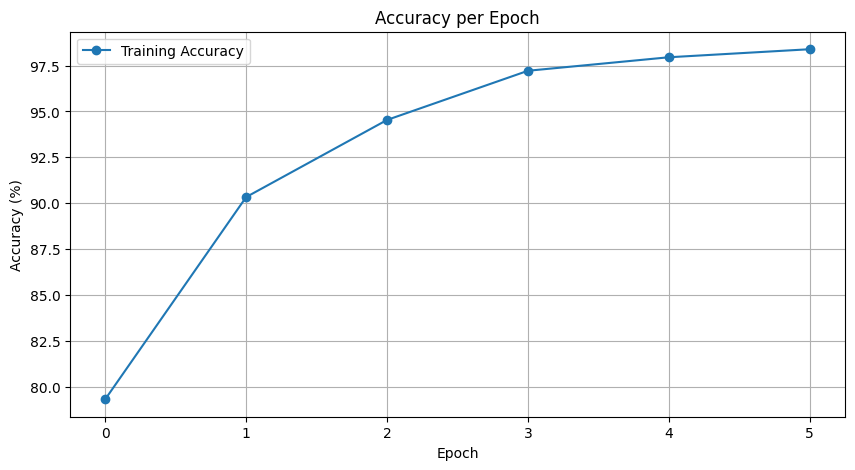

In [ ]:
import matplotlib.pyplot as plt

num_epochs = 6
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    MRI_CNN_Net.train()
    correct = 0
    total = 0
    running_loss = 0.0

    for inputs, labels in training_loader:
        optimizer.zero_grad()
        outputs = MRI_CNN_Net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_accuracies.append(train_accuracy)
    print(f"Epoch {epoch+1}: Training Accuracy = {train_accuracy:.2f}%")

    # Validation accuracy (optional, only if you have a validation_loader)
    if 'validation_loader' in globals():
        MRI_CNN_Net.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in validation_loader:
                outputs = MRI_CNN_Net(inputs)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total
        val_accuracies.append(val_accuracy)
        print(f"Epoch {epoch+1}: Validation Accuracy = {val_accuracy:.2f}%")

# Plotting
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Training Accuracy', marker='o')
if val_accuracies:
    plt.plot(val_accuracies, label='Validation Accuracy', marker='x')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


## Saving our trained model

In [ ]:
PATH = './mri_brain_tumor_resnet.pth'
torch.save(MRI_CNN_Net.state_dict(), PATH)

## Showing some images from our test set

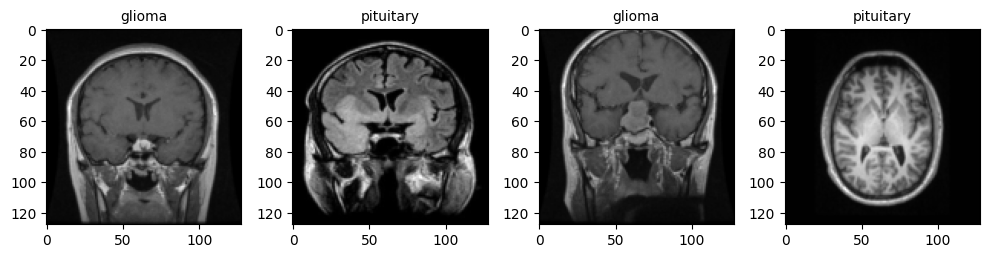

In [ ]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

images, labels = next(iter(training_loader))  # one batch

plt.figure(figsize=(10, 6))
for i in range(4):
    img = images[i].squeeze(0)
    plt.subplot(1, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(classes[labels[i]], fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
def test_model(model, test_loader):
    model.eval()  # set to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # disable gradient tracking
        for images, labels in test_loader:
            outputs = MRI_CNN_Net(images)
            _, predicted = torch.max(outputs, 1)  # get class with highest score
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')

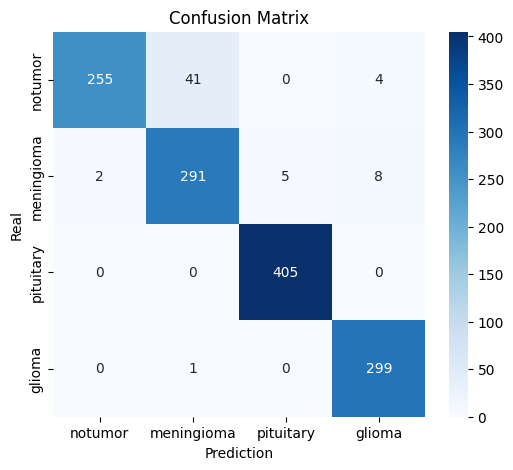

              precision    recall  f1-score   support

     notumor       0.99      0.85      0.92       300
  meningioma       0.87      0.95      0.91       306
   pituitary       0.99      1.00      0.99       405
      glioma       0.96      1.00      0.98       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.96      0.95      0.95      1311



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []

MRI_CNN_Net.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = MRI_CNN_Net(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Prediction")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

# Precision, Recall, F1
print(classification_report(all_labels, all_preds, target_names=classes))


In [ ]:
test_model(MRI_CNN_Net, test_loader)

Test Accuracy: 95.35%
